In [2]:
import os
import time
import numpy as np
import polars as pl
import optuna
import psutil
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

HAS_GPU = len(tf.config.list_physical_devices('GPU')) > 0
TRAIN_DEVICE = '/GPU:0' if HAS_GPU else '/CPU:0'
INFER_DEVICE = '/CPU:0'

if HAS_GPU:
    print('GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.')
else:
    print('No hay GPU disponible. Entrenamiento e inferencia se ejecutaran en CPU.')

tf.keras.backend.clear_session()

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1777835592.937160 1513942 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777835592.984909 1513942 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777835594.178550 1513942 port.cc:153] oneDNN custom operati

GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.


In [3]:
DEFAULT_DROPOUT_RATE = 0.2

# CORRECCIÓN: Quitamos time_steps. La entrada es (n_features, 1)
def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_DROPOUT_RATE):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)), # <-- Forma tabular para CNN-1D
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def clone_model_to_cpu(trained_model, n_features, n_filters, kernel_size, dense_units, dropout_rate):
    with tf.device(INFER_DEVICE):
        cpu_model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

In [4]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [4]:
# ==========================================
# 2. OPTUNA MULTIOBJETIVO: F1 Y LATENCIA
# ==========================================

def objective(trial):
    tf.keras.backend.clear_session()

    n_filters = trial.suggest_int('n_filters', 32, 128, step=32)
    # kernel_size no puede ser mayor que tu número de características. 2, 3 o 5 son ideales.
    kernel_size = trial.suggest_int('kernel_size', 2, 5) 
    dense_units = trial.suggest_int('dense_units', 16, 96, step=16)
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    inference_times = []

    for train_idx, val_idx in skf.split(X_full_train_np, y_full_train):
        X_train_fold = X_full_train_np[train_idx]
        y_train_fold = y_full_train[train_idx]
        X_val_fold = X_full_train_np[val_idx]
        y_val_fold = y_full_train[val_idx]

        # 1. Escalado Min-Max (El recomendado para Redes Neuronales y CNN)
        scaler = MinMaxScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # Pasamos de (muestras, variables) a (muestras, variables, 1 canal)
        X_train_cnn = X_train_fold_scaled.reshape(X_train_fold_scaled.shape[0], X_train_fold_scaled.shape[1], 1)
        X_val_cnn = X_val_fold_scaled.reshape(X_val_fold_scaled.shape[0], X_val_fold_scaled.shape[1], 1)

        n_features = X_train_cnn.shape[1]

        with tf.device(INFER_DEVICE): # He tenido que poner entrenamiento con CPU ya que no me funciona con GPU
            model = build_cnn1d_model(
                n_features=n_features,
                n_filters=n_filters,
                kernel_size=kernel_size,
                dense_units=dense_units,
                dropout_rate=DEFAULT_DROPOUT_RATE
            )

            early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            model.fit(
                X_train_cnn,  # Usamos el array reshaped
                y_train_fold, # Las etiquetas directas, sin secuencias
                validation_split=0.1,
                epochs=20,
                batch_size=1024,
                callbacks=[early_stop],
                verbose=0
            )

        # Clonado para inferencia
        cpu_model = clone_model_to_cpu(
            trained_model=model,
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        with tf.device(INFER_DEVICE):
            y_pred_prob = cpu_model.predict(X_val_cnn, batch_size=1024, verbose=0).ravel()

        y_pred = (y_pred_prob > 0.5).astype(np.int8)
        f1_scores.append(f1_score(y_val_fold, y_pred, average='binary', zero_division=0))

        # Medición de Latencia
        X_lat = X_val_cnn[:min(20000, len(X_val_cnn))]
        if len(X_lat) == 0:
            continue

        with tf.device(INFER_DEVICE):
            _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

        rep_lat = []
        for _ in range(3):
            with tf.device(INFER_DEVICE):
                t0 = time.perf_counter()
                _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
                t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat))

        inference_times.append(float(np.mean(rep_lat)))

        tf.keras.backend.clear_session()

    return float(np.mean(f1_scores)), float(np.mean(inference_times))


study = optuna.create_study(directions=['maximize', 'minimize'], study_name='cnn1d_ids_optimization')
print('Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU si existe, inferencia medida en CPU)...')
study.optimize(objective, n_trials=25, show_progress_bar=True)

results = []
pareto_trials = {trial.number for trial in study.best_trials}
for trial in study.trials:
    if trial.values is None:
        continue

    row = {
        'Trial': trial.number,
        'F1_CV': float(trial.values[0]),
        'Latencia_ms': float(trial.values[1] * 1000),
        'Pareto': trial.number in pareto_trials
    }
    row.update(trial.params)
    results.append(row)

df_cnn_trials = pl.DataFrame(results).sort(['Pareto', 'F1_CV', 'Latencia_ms'], descending=[True, True, False])
df_cnn_trials.write_csv('cnn1d_ton_trials_results_cv.csv')
print("\nResultados guardados en 'cnn1d_ton_trials_results_cv.csv'")
print(df_cnn_trials)


[I 2026-05-02 12:10:15,200] A new study created in memory with name: cnn1d_ids_optimization


Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU si existe, inferencia medida en CPU)...


  0%|          | 0/25 [00:00<?, ?it/s]I0000 00:00:1777716615.831946  554213 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43487 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1777716615.833073  554213 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43487 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1777716615.834391  554213 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43487 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1777716615.835418  554213 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43487 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
W0000 00:00:1777716616.842931  555173 platform_util.cc:146] Allowe

[I 2026-05-02 12:11:51,518] Trial 0 finished with values: [0.9804042287116462, 9.246357795523685e-06] and parameters: {'n_filters': 96, 'kernel_size': 5, 'dense_units': 96}.


  8%|▊         | 2/25 [03:19<38:32, 100.53s/it]

...

[I 2026-05-02 12:42:02,824] Trial 22 finished with values: [0.9773972093481428, 9.0761033734048e-06] and parameters: {'n_filters': 64, 'kernel_size': 5, 'dense_units': 48}.


 96%|█████████▌| 24/25 [33:22<01:24, 84.26s/it]

[I 2026-05-02 12:43:37,573] Trial 23 finished with values: [0.9781155790612077, 9.554706366422275e-06] and parameters: {'n_filters': 96, 'kernel_size': 4, 'dense_units': 64}.


100%|██████████| 25/25 [35:10<00:00, 84.42s/it]

[I 2026-05-02 12:45:25,672] Trial 24 finished with values: [0.9763358161709633, 9.520930196029237e-06] and parameters: {'n_filters': 128, 'kernel_size': 3, 'dense_units': 64}.

Resultados guardados en 'cnn1d_ton_trials_results_cv.csv'
shape: (25, 7)
┌───────┬──────────┬─────────────┬────────┬───────────┬─────────────┬─────────────┐
│ Trial ┆ F1_CV    ┆ Latencia_ms ┆ Pareto ┆ n_filters ┆ kernel_size ┆ dense_units │
│ ---   ┆ ---      ┆ ---         ┆ ---    ┆ ---       ┆ ---         ┆ ---         │
│ i64   ┆ f64      ┆ f64         ┆ bool   ┆ i64       ┆ i64         ┆ i64         │
╞═══════╪══════════╪═════════════╪════════╪═══════════╪═════════════╪═════════════╡
│ 18    ┆ 0.980745 ┆ 0.009517    ┆ true   ┆ 128       ┆ 5           ┆ 96          │
│ 0     ┆ 0.980404 ┆ 0.009246    ┆ true   ┆ 96        ┆ 5           ┆ 96          │
│ 5     ┆ 0.97852  ┆ 0.009004    ┆ true   ┆ 64        ┆ 5           ┆ 64          │
│ 12    ┆ 0.978203 ┆ 0.00899     ┆ true   ┆ 96        ┆ 4           ┆ 80      

Trial,F1_CV,Latencia_ms,Pareto,n_filters,kernel_size,dense_units
i64,f64,f64,bool,i64,i64,i64
2,0.973066,0.008376,true,32,4,64
13,0.977295,0.008531,true,32,4,80
12,0.978203,0.00899,true,96,4,80
5,0.97852,0.009004,true,64,5,64
0,0.980404,0.009246,true,96,5,96
18,0.980745,0.009517,true,128,5,96


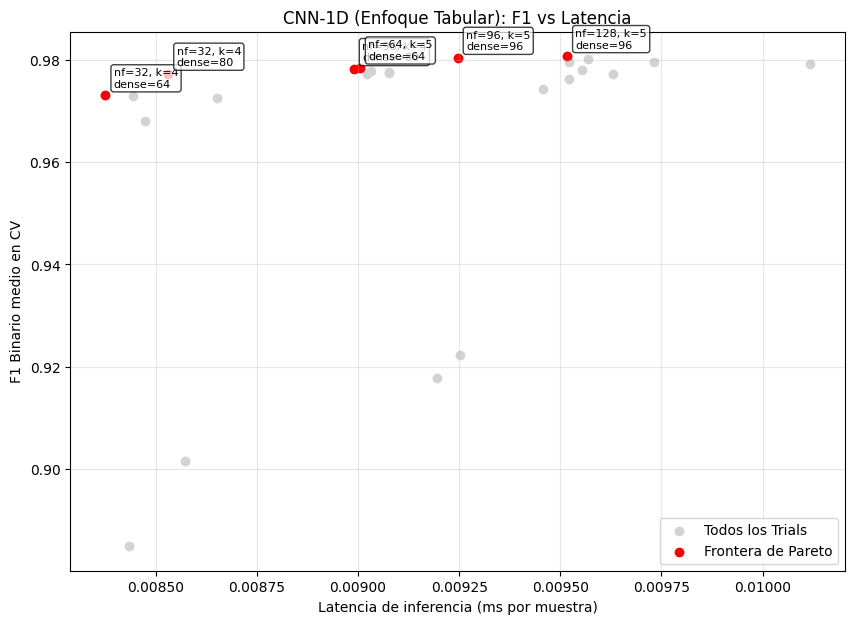

In [5]:
import polars as pl
import matplotlib.pyplot as plt

# Leer resultados desde el CSV
df_cnn_trials = pl.read_csv("cnn1d_ton_trials_results_cv.csv")

# Filtrar frontera de Pareto
df_pareto = (
    df_cnn_trials
    .filter(pl.col("Pareto") == True)
    .sort("Latencia_ms")
)

display(df_pareto)

plt.figure(figsize=(10, 7))

# Puntos grises para todos los intentos
plt.scatter(
    df_cnn_trials["Latencia_ms"],
    df_cnn_trials["F1_CV"],
    c="lightgray",
    label="Todos los Trials"
)

# Puntos rojos para los óptimos (Pareto)
plt.scatter(
    df_pareto["Latencia_ms"],
    df_pareto["F1_CV"],
    c="red",
    label="Frontera de Pareto"
)

# Mostrar hiperparámetros de los puntos Pareto (SIN time_steps)
for row in df_pareto.iter_rows(named=True):
    texto = (
        f"nf={row['n_filters']}, k={row['kernel_size']}\n"
        f"dense={row['dense_units']}"
    )
    plt.annotate(
        texto,
        (row["Latencia_ms"], row["F1_CV"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.75)
    )

plt.xlabel("Latencia de inferencia (ms por muestra)")
plt.ylabel("F1 Binario medio en CV")
plt.title("CNN-1D (Enfoque Tabular): F1 vs Latencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
import gc
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# 4. EVALUACION FINAL EN TEST (CNN-1D TABULAR)
# ==========================================

# OJO: Pon aquí los hiperparámetros de los mejores trials que te dio Optuna
candidatos = [
    {'nf': 32, 'k': 4, 'd': 64, 'nombre': 'Candidato 1'},
    {'nf': 32, 'k': 4, 'd': 80, 'nombre': 'Candidato 2'},
    {'nf': 96, 'k': 4, 'd': 80, 'nombre': 'Candidato 3'},
    {'nf': 64, 'k': 5, 'd': 64, 'nombre': 'Candidato 4'},
    {'nf': 96, 'k': 5, 'd': 96, 'nombre': 'Candidato 5'},
    {'nf': 128, 'k': 5, 'd': 96, 'nombre': 'Candidato 6'},
]

resultados_finales = []

print('--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D ENFOQUE TABULAR) ---\n')

for c in candidatos:
    tf.keras.backend.clear_session()
    print(
        f"Probando {c['nombre']}: Filtros={c['nf']}, "
        f"Kernel={c['k']}, Dense={c['d']}"
    )

    n_filters = int(c['nf'])
    kernel_size = int(c['k'])
    dense_units = int(c['d'])

    # 1. Escalado Min-Max (Obligatorio para CNN)
    scaler = MinMaxScaler()
    X_full_train_scaled = scaler.fit_transform(X_full_train_np) 
    X_test_scaled = scaler.transform(X_test_np)

    # 2. Reshape Tabular (muestras, features, 1)
    X_train_cnn = X_full_train_scaled.reshape(X_full_train_scaled.shape[0], X_full_train_scaled.shape[1], 1)
    X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    n_features = X_train_cnn.shape[1]

    with tf.device(INFER_DEVICE):
        model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(
            X_train_cnn,
            y_full_train, # Usamos las etiquetas 0/1 que definiste en tu código general
            validation_split=0.1,
            epochs=20,
            batch_size=1024,
            callbacks=[early_stop],
            verbose=0
        )

    # Clonado a CPU para medir latencia de inferencia pura
    cpu_model = clone_model_to_cpu(
        trained_model=model,
        n_features=n_features,
        n_filters=n_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout_rate=DEFAULT_DROPOUT_RATE
    )

    with tf.device(INFER_DEVICE):
        y_prob = cpu_model.predict(X_test_cnn, batch_size=1024, verbose=0).ravel()
    
    y_pred = (y_prob > 0.5).astype(np.int8)

    # Medición de latencia
    X_lat = X_test_cnn[:min(20000, len(X_test_cnn))]
    if len(X_lat) == 0:
        raise ValueError('No hay suficientes muestras en test para medir latencia con la configuracion seleccionada.')

    with tf.device(INFER_DEVICE):
        _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

    rep_lat = []
    for _ in range(3):
        with tf.device(INFER_DEVICE):
            t0 = time.perf_counter()
            _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
            t1 = time.perf_counter()
        rep_lat.append((t1 - t0) / len(X_lat))

    # Cálculo de métricas
    f1_test = float(f1_score(y_test_np, y_pred, average='binary', zero_division=0))
    acc_test = float(accuracy_score(y_test_np, y_pred))
    lat_ms = float(np.mean(rep_lat) * 1000)

    resultados_finales.append({
        'Perfil': c['nombre'],
        'n_filters': n_filters,
        'kernel_size': kernel_size,
        'dense_units': dense_units,
        'F1_Test': f1_test,
        'Accuracy_Test': acc_test,
        'Latencia_ms': lat_ms
    })
    print(f"  -> F1={f1_test:.4f} | Acc={acc_test:.4f} | Latencia={lat_ms:.6f} ms")

    # Limpieza estricta de memoria entre candidatos
    del model
    del cpu_model
    tf.keras.backend.clear_session()
    gc.collect()

# Mostrar resultados
df_candidate_results = pl.DataFrame(resultados_finales).sort(['F1_Test', 'Latencia_ms'], descending=[True, False])

print('\n' + '=' * 88)
print('              TABLA COMPARATIVA FINAL (CNN-1D - TEST SET)')
print('=' * 88)
print(df_candidate_results)

--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D ENFOQUE TABULAR) ---

Probando Candidato 1: Filtros=32, Kernel=4, Dense=64


I0000 00:00:1777835606.093669 1513942 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43487 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1777835606.095103 1513942 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43487 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1777835606.096445 1513942 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43487 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1777835606.097476 1513942 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43487 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
W0000 00:00:1777835607.075612 1653761 platform_util.cc:146] Allowed device set contains 4 devices, but p

  -> F1=0.9779 | Acc=0.9659 | Latencia=0.008596 ms
Probando Candidato 2: Filtros=32, Kernel=4, Dense=80
  -> F1=0.9750 | Acc=0.9612 | Latencia=0.009421 ms
Probando Candidato 3: Filtros=96, Kernel=4, Dense=80
  -> F1=0.9784 | Acc=0.9667 | Latencia=0.009012 ms
Probando Candidato 4: Filtros=64, Kernel=5, Dense=64
  -> F1=0.9812 | Acc=0.9708 | Latencia=0.009133 ms
Probando Candidato 5: Filtros=96, Kernel=5, Dense=96
  -> F1=0.9818 | Acc=0.9718 | Latencia=0.008953 ms
Probando Candidato 6: Filtros=128, Kernel=5, Dense=96
  -> F1=0.9817 | Acc=0.9716 | Latencia=0.009564 ms

              TABLA COMPARATIVA FINAL (CNN-1D - TEST SET)
shape: (6, 7)
┌─────────────┬───────────┬─────────────┬─────────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ n_filters ┆ kernel_size ┆ dense_units ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---       ┆ ---         ┆ ---         ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ i64       ┆ i64         ┆ i64         ┆ f64     